In [1]:
"""
Notebook para treino do modelo de previsão hidrológica.
"""

# Célula 1: Importações
import sys
import os
import pathlib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src import (
    ConfigLoader, load_feature_config, load_split_config, load_config,
    HydroDataset, create_temporal_split_with_gap,
    Seq2SeqHydro, train_model, predict_autoregressive,
    custom_collate_fn
)

# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")


📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed


In [5]:
# Célula 2: Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

# Extrair configurações
stations = data_config["stations"]
flow_window_config = data_config["flow_window_config"]
climate_window_config = data_config["climate_window_config"]
temporal_features = data_config["temporal_features"]
api_k_list = data_config["feature_windows"]["api_k_list"]
static_keys = data_config["static_keys"]
static_attributes_dict = data_config["static_attributes"]  # ← NOVO

print(f"✓ {len(stations)} estações carregadas")
print(f"✓ Configurações de modelo carregadas")
print(f"✓ Configurações de treino carregadas")
print(f"✓ Atributos estáticos de {len(static_attributes_dict)} estações carregados")

# Célula 3: Carregar dados processados
print("\n📊 Carregando dados processados...")
features_file = PROCESSED_DIR / "features_combined.csv"

if not features_file.exists():
    raise FileNotFoundError(f"Arquivo de features não encontrado: {features_file}")

combined_df = pd.read_csv(features_file)
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')

print(f"✓ Dados carregados: {len(combined_df)} dias")
print(f"  Período: {combined_df.index.min().date()} a {combined_df.index.max().date()}")
print(f"  Colunas: {len(combined_df.columns)}")


⚙️ Carregando configurações...
✓ 3 estações carregadas
✓ Configurações de modelo carregadas
✓ Configurações de treino carregadas
✓ Atributos estáticos de 3 estações carregados

📊 Carregando dados processados...
✓ Dados carregados: 6330 dias
  Período: 1995-01-01 a 2012-04-30
  Colunas: 133


In [ ]:
# Criar forecast columns (mesmos dados para início)
forecast_cols = {}
for station in stations:
    forecast_cols[station] = (
        f'precipitation_forecast_{station}',
        f'potential_evapotransp_forecast_{station}'
    )

In [ ]:
# Criar dataset
print("\n📦 Criando dataset...")
train_ratio = data_config.get("train_ratio", 0.95)
train_indices = np.arange(0, int(len(combined_df) * train_ratio))

dataset = HydroDataset(
    df=combined_df,
    stations=stations,
    static_attrs=static_attributes_dict,
    train_indices=train_indices,
    forecast_cols=forecast_cols,
    flow_window_config=flow_window_config,
    climate_window_config=climate_window_config,
    temporal_features=temporal_features,
    api_k_list=api_k_list,
    static_keys=static_keys,
    window_stride=data_config.get("window_stride", 1),
)

print(f"✓ Dataset criado")
print(f"  Total de samples: {len(dataset)}")
print(f"  Encoder length: {dataset.encoder_length}")
print(f"  Decoder length: {dataset.decoder_length}")
print(f"  Decoder history: {dataset.decoder_history}")
print(f"  Decoder horizon: {dataset.decoder_horizon}")


📦 Criando dataset...
✓ Dataset criado
  Total de samples: 5933
  Encoder length: 380
  Decoder length: 153
  Decoder history: 135
  Decoder horizon: 18


In [8]:
# Célula 7: Split temporal
print("\n✂️ Criando split temporal...")
train_ds, val_ds = create_temporal_split_with_gap(
    dataset, 
    train_ratio=train_ratio,
    gap=data_config.get("gap", 128)
)

print(f"✓ Split criado")
print(f"  Treino: {len(train_ds)} samples")
print(f"  Validação: {len(val_ds)} samples")


✂️ Criando split temporal...
✓ Split criado
  Treino: 5636 samples
  Validação: 297 samples


In [10]:
# Célula 8: Criar DataLoaders
print("\n🔄 Criando DataLoaders...")
batch_size = train_config.get("batch_size", 64)

train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True, 
    collate_fn=custom_collate_fn
)

val_loader = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=custom_collate_fn
)

print(f"✓ DataLoaders criados")
print(f"  Batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")



🔄 Criando DataLoaders...
✓ DataLoaders criados
  Batch size: 64
  Train batches: 88
  Val batches: 5


In [11]:
# Célula 9: Verificar dimensões
print("\n📐 Verificando dimensões...")
sample = dataset[0]

encoder_input_dim = sample.encoder_dyn.shape[-1]
decoder_dyn_features = sample.decoder_dyn.shape[-1]
temporal_features_dim = sample.temporal_dec.shape[-1]
n_stations = len(stations)
decoder_input_dim = decoder_dyn_features + temporal_features_dim + n_stations
static_dim = sample.static.shape[-1]

print(f"✓ Dimensões calculadas:")
print(f"  Encoder input dim: {encoder_input_dim}")
print(f"  Decoder input dim: {decoder_input_dim}")
print(f"  Static dim: {static_dim}")
print(f"  N stations: {n_stations}")



📐 Verificando dimensões...
✓ Dimensões calculadas:
  Encoder input dim: 21
  Decoder input dim: 58
  Static dim: 12
  N stations: 3


In [12]:
# Célula 10: Criar modelo
print("\n🧠 Criando modelo...")
device = get_device(model_config)

# Extrair parâmetros do modelo
arch_config = model_config["architecture"]
gate_config = model_config["gate"]
reg_config = model_config["regularization"]

model = Seq2SeqHydro(
    encoder_input_dim=encoder_input_dim,
    decoder_input_dim=decoder_input_dim,
    n_static=static_dim,
    hidden_dim=arch_config["hidden_dim"],
    num_layers=arch_config["num_layers"],
    dropout=arch_config["dropout"],
    n_stations=n_stations,
    attention=arch_config["attention"],
    residual=arch_config["residual"],
    non_negative=arch_config["non_negative"],
    input_noise_std=reg_config["input_noise_std"],
    y_prev_dropout_p=reg_config["y_prev_dropout_p"],
    gate_y_prev=gate_config["y_prev"],
    tf_step_decay=reg_config["tf_step_decay"],
    y_prev_mask_p=reg_config["y_prev_mask_p"],
    decoder_feat_dropout_p=reg_config["decoder_feat_dropout_p"],
    gate_from_inputs=gate_config["from_inputs"],
    clamp_gate_by_ceiling=gate_config["clamp_by_ceiling"],
    gate_ceiling_min=gate_config["ceiling_min"],
    detach_y_prev_in_gate=gate_config["detach_y_prev"],
    y_prev_mask_step_gamma=reg_config["y_prev_mask_step_gamma"],
    gate_min=gate_config["min"],
    gate_max=gate_config["max"],
)

print(f"✓ Modelo criado")
print(f"  Parâmetros totais: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device: {device}")


🧠 Criando modelo...
⚠️ CUDA não disponível, usando CPU
✓ Modelo criado
  Parâmetros totais: 3,135,750
  Device: cpu


In [13]:
# Célula 11: Treinar modelo
print("\n🚀 Iniciando treino...")
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    decoder_history=dataset.decoder_history,
    decoder_horizon=dataset.decoder_horizon,
    max_epochs=train_config["epochs"],
    initial_teacher_forcing=train_config["teacher_forcing"]["initial"],
    teacher_forcing_decay=train_config["teacher_forcing"]["decay"],
    final_teacher_forcing=train_config["teacher_forcing"]["final"],
    free_run_tail=train_config["teacher_forcing"]["free_run_tail"],
    lambda_smooth=train_config["loss_weights"]["smooth"],
    lambda_negative=train_config["loss_weights"]["negative"],
    lambda_continuity=train_config["loss_weights"]["continuity"],
    lambda_slope=train_config["loss_weights"]["slope"],
    horizon_weight_mode=train_config["horizon_weights"]["mode"],
    horizon_weight_gamma=train_config["horizon_weights"]["gamma"],
    early_free_run_patience=train_config["teacher_forcing"]["early_free_run_patience"],
    lambda_gate_bias=train_config["loss_weights"]["gate_bias"],
    gate_decay=train_config["gate_decay"],
    lambda_direction=train_config["loss_weights"]["direction"],
    direction_start=train_config["direction"]["start"],
    dir_weight_gamma=train_config["direction"]["weight_gamma"],
    patience=train_config["early_stopping"]["patience"],
    min_delta=train_config["early_stopping"]["min_delta"],
    learning_rate=train_config["learning_rate"],
    weight_decay=train_config["weight_decay"],
    clip_grad_norm=train_config["clip_grad_norm"],
    device=device,
)

print("✓ Treino concluído!")


🚀 Iniciando treino...
[Epoch 01] train=0.5445 val=0.0629 tf=0.600
[Epoch 02] train=0.0336 val=0.0510 tf=0.564
[Epoch 03] train=0.0317 val=0.0492 tf=0.530
[Epoch 04] train=0.0304 val=0.0459 tf=0.498
[Epoch 05] train=0.0279 val=0.0418 tf=0.468
[Epoch 06] train=0.0266 val=0.0456 tf=0.440
[Epoch 07] train=0.0241 val=0.0502 tf=0.414
[Epoch 08] train=0.0241 val=0.0477 tf=0.389
[Epoch 09] train=0.0242 val=0.0493 tf=0.366
[Epoch 10] train=0.0224 val=0.0566 tf=0.344
[Epoch 11] train=0.0212 val=0.0526 tf=0.323
[Epoch 12] train=0.0207 val=0.0582 tf=0.304
[Epoch 13] train=0.0187 val=0.0513 tf=0.286
[Epoch 14] train=0.0183 val=0.0530 tf=0.268
[Epoch 15] train=0.0180 val=0.0567 tf=0.252
Early stopping.
✓ Treino concluído!


In [14]:
# Célula 12: Fazer previsões
print("\n🔮 Fazendo previsões...")
preds, obs, baseline_last, g_seq, forecast_dates, _ = predict_autoregressive(
    model=trained_model,
    loader=val_loader,
    decoder_history=dataset.decoder_history,
    decoder_horizon=dataset.decoder_horizon,
    scalers=dataset.flow_scalers,
    stations=stations,
    clamp_non_negative=True,
    device=device,
)

print(f"✓ Previsões realizadas")
print(f"  Shape preds: {preds.shape}")
print(f"  Shape obs: {obs.shape}")
print(f"  N forecast dates: {len(forecast_dates)}")



🔮 Fazendo previsões...
✓ Previsões realizadas
  Shape preds: (297, 18, 3)
  Shape obs: (297, 18, 3)
  N forecast dates: 297



📊 Análise básica das previsões...

Estação 10100000:
  RMSE: 2488.380 (persistência: 3725.412)
  NSE:  0.966 (persistência: 0.924)
  KGE:  0.971 (persistência: 0.946)

Estação 13150000:
  RMSE: 1835.903 (persistência: 7136.544)
  NSE:  0.995 (persistência: 0.918)
  KGE:  0.988 (persistência: 0.958)

Estação 14100000:
  RMSE: 1734.569 (persistência: 8423.128)
  NSE:  0.997 (persistência: 0.930)
  KGE:  0.992 (persistência: 0.965)

📈 Criando visualizações...

Estação 10100000:


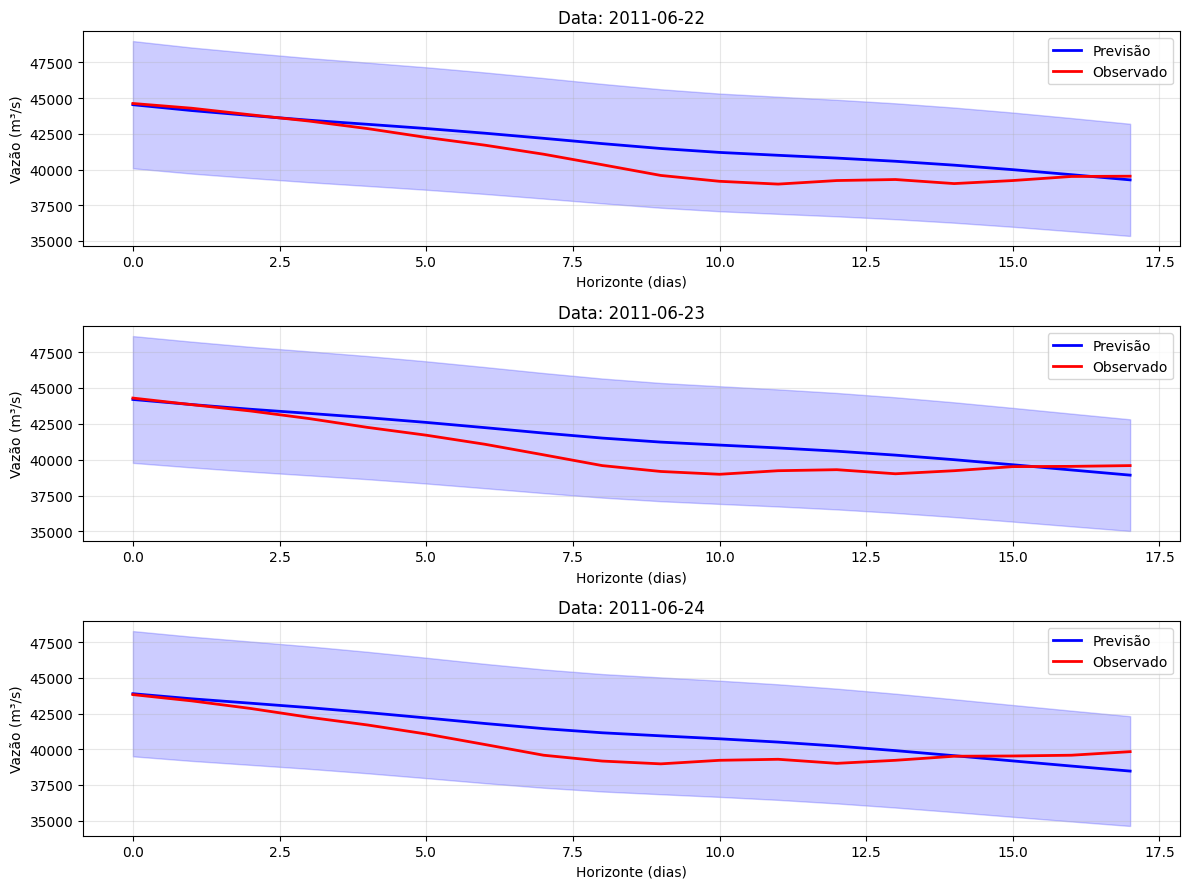


Estação 13150000:


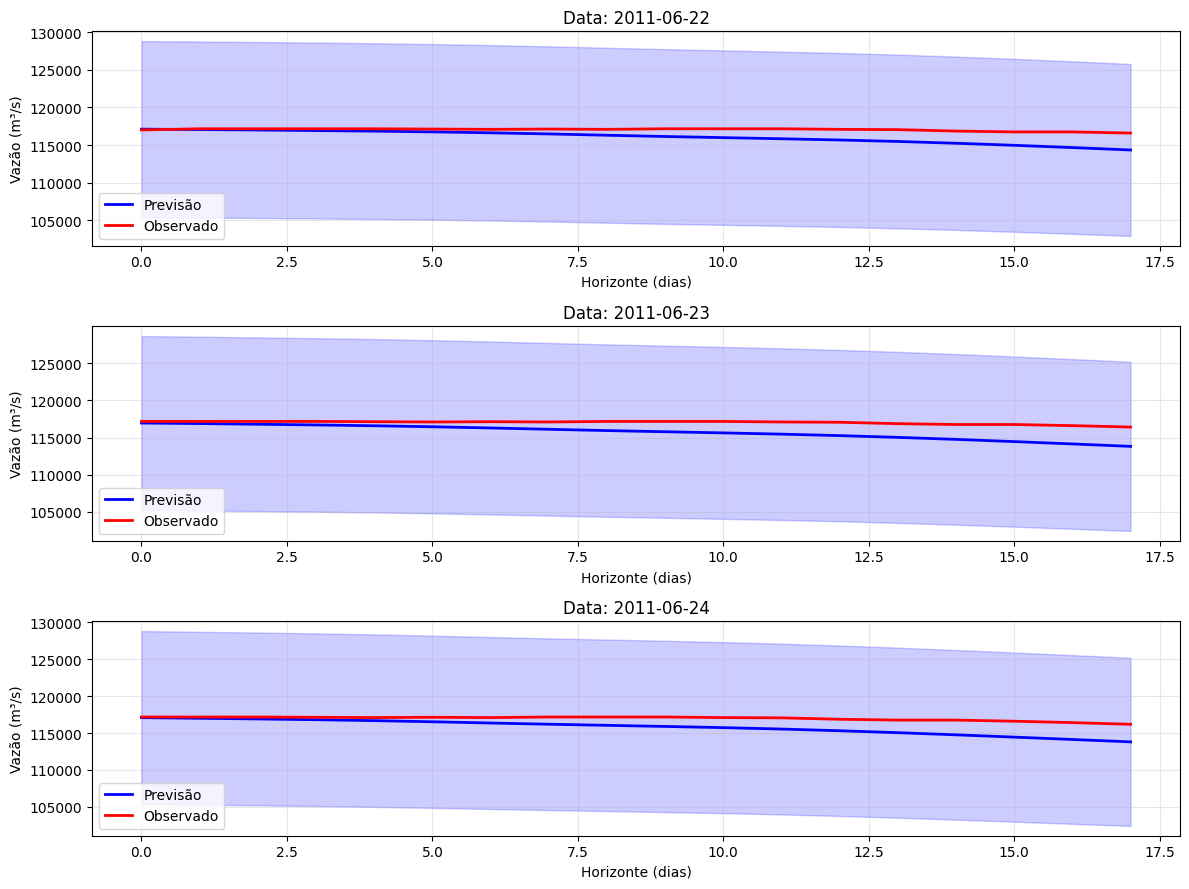


Estação 14100000:


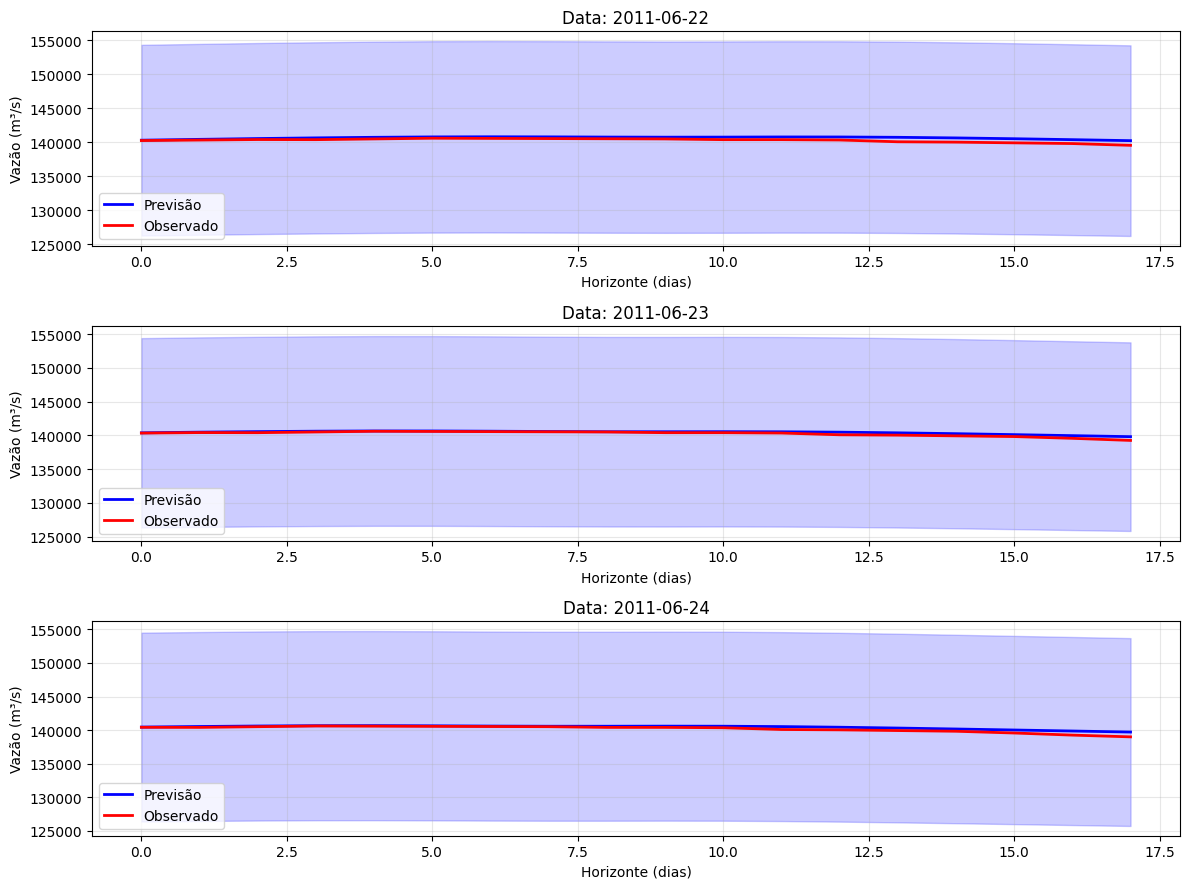


💾 Salvando modelo...
✓ Modelo salvo em: c:\Users\emily\Documents\TCC_projeto_teste\Modelo1\models\seq2seq_hydro.pth

💾 Salvando previsões...
✓ Previsões salvas em: c:\Users\emily\Documents\TCC_projeto_teste\Modelo1\predictions

PROCESSO CONCLUÍDO COM SUCESSO!


: 

In [ ]:
# Célula 13: Análise básica
print("\n📊 Análise básica das previsões...")

# Calcular métricas simples
def calculate_metrics(preds, obs, baseline):
    """Calcula métricas básicas."""
    # RMSE
    rmse = np.sqrt(np.mean((preds - obs) ** 2, axis=(0, 1)))
    
    # NSE (Nash-Sutcliffe Efficiency)
    mean_obs = np.mean(obs, axis=(0, 1))
    nse = 1 - np.sum((preds - obs) ** 2, axis=(0, 1)) / np.sum((obs - mean_obs) ** 2, axis=(0, 1))
    
    # KGE (Kling-Gupta Efficiency)
    r = np.corrcoef(preds.flatten(), obs.flatten())[0, 1]
    alpha = np.std(preds) / np.std(obs)
    beta = np.mean(preds) / np.mean(obs)
    kge = 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)
    
    return rmse, nse, kge

# Métricas por estação
for i, station in enumerate(stations):
    station_preds = preds[:, :, i]
    station_obs = obs[:, :, i]
    station_baseline = baseline_last[:, i]
    
    # Persistência (última observação)
    persistence = np.tile(station_baseline[:, np.newaxis], (1, station_preds.shape[1]))
    
    rmse_pred, nse_pred, kge_pred = calculate_metrics(
        station_preds, station_obs, station_baseline
    )
    rmse_pers, nse_pers, kge_pers = calculate_metrics(
        persistence, station_obs, station_baseline
    )
    
    print(f"\nEstação {station}:")
    print(f"  RMSE: {rmse_pred:.3f} (persistência: {rmse_pers:.3f})")
    print(f"  NSE:  {nse_pred:.3f} (persistência: {nse_pers:.3f})")
    print(f"  KGE:  {kge_pred:.3f} (persistência: {kge_pers:.3f})")

# Célula 14: Visualizações
print("\n📈 Criando visualizações...")

# Função para plotar previsões
def plot_predictions_sample(preds, obs, forecast_dates, station_idx, n_samples=5):
    """Plota amostras de previsões."""
    fig, axes = plt.subplots(n_samples, 1, figsize=(12, 3*n_samples))
    
    if n_samples == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        if i >= len(preds):
            break
            
        horizon = preds.shape[1]
        ax.plot(range(horizon), preds[i, :, station_idx], 'b-', label='Previsão', linewidth=2)
        ax.plot(range(horizon), obs[i, :, station_idx], 'r-', label='Observado', linewidth=2)
        ax.fill_between(range(horizon), 
                       preds[i, :, station_idx] * 0.9, 
                       preds[i, :, station_idx] * 1.1, 
                       alpha=0.2, color='blue')
        
        ax.set_title(f"Data: {forecast_dates[i].date()}")
        ax.set_xlabel("Horizonte (dias)")
        ax.set_ylabel("Vazão (m³/s)")
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot para cada estação
for i, station in enumerate(stations):
    print(f"\nEstação {station}:")
    plot_predictions_sample(preds, obs, forecast_dates, i, n_samples=3)

# Célula 15: Salvar modelo (opcional)
print("\n💾 Salvando modelo...")
models_dir = root_folder / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "seq2seq_hydro.pth"
torch.save(trained_model.state_dict(), model_path)
print(f"✓ Modelo salvo em: {model_path}")

# Célula 16: Salvar previsões (opcional)
print("\n💾 Salvando previsões...")
predictions_dir = root_folder / "predictions"
predictions_dir.mkdir(exist_ok=True)

# Salvar como numpy arrays
np.save(predictions_dir / "predictions.npy", preds)
np.save(predictions_dir / "observations.npy", obs)
np.save(predictions_dir / "baseline.npy", baseline_last)
np.save(predictions_dir / "forecast_dates.npy", forecast_dates)

if g_seq is not None:
    np.save(predictions_dir / "gates.npy", g_seq)

print(f"✓ Previsões salvas em: {predictions_dir}")

print("\n" + "="*60)
print("PROCESSO CONCLUÍDO COM SUCESSO!")
print("="*60)